# Air Quality Data in India | City Day | EDA

# Loading the libraries

In [74]:
import numpy as np 
import matplotlib.pyplot as plt
import seaborn as sns
import pandas as pd

# Loading the dataset

In [75]:
cd = pd.read_csv("C:\\Downloads\\Python-Data Science\\submissions\\Practical-4\\city_day.csv")
cd.head(5)

,City,Date,PM2.5,PM10,NO,NO2,NOx,NH3,CO,SO2,O3,Benzene,Toluene,Xylene,AQI,AQI_Bucket
0,Ahmedabad,2015-01-01,NaN,NaN,0.92,18.22,17.15,NaN,0.92,27.64,133.36,0.00,0.02,0.00,NaN,NaN
1,Ahmedabad,2015-01-02,NaN,NaN,0.97,15.69,16.46,NaN,0.97,24.55,34.06,3.68,5.50,3.77,NaN,NaN
2,Ahmedabad,2015-01-03,NaN,NaN,17.40,19.30,29.70,NaN,17.40,29.07,30.70,6.80,16.40,2.25,NaN,NaN
3,Ahmedabad,2015-01-04,NaN,NaN,1.70,18.48,17.97,NaN,1.70,18.59,36.08,4.43,10.14,1.00,NaN,NaN
4,Ahmedabad,2015-01-05,NaN,NaN,22.10,21.42,37.76,NaN,22.10,39.33,39.31,7.01,18.89,2.78,NaN,NaN


In [76]:
cd.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 29531 entries, 0 to 29530
Data columns (total 16 columns):
 #   Column      Non-Null Count  Dtype  
---  ------      --------------  -----  
 0   City        29531 non-null  object 
 1   Date        29531 non-null  object 
 2   PM2.5       24933 non-null  float64
 3   PM10        18391 non-null  float64
 4   NO          25949 non-null  float64
 5   NO2         25946 non-null  float64
 6   NOx         25346 non-null  float64
 7   NH3         19203 non-null  float64
 8   CO          27472 non-null  float64
 9   SO2         25677 non-null  float64
 10  O3          25509 non-null  float64
 11  Benzene     23908 non-null  float64
 12  Toluene     21490 non-null  float64
 13  Xylene      11422 non-null  float64
 14  AQI         24850 non-null  float64
 15  AQI_Bucket  24850 non-null  object 
dtypes: float64(13), object(3)
memory usage: 3.6+ MB


# Data Cleaning and Preparation

In [77]:
# Check for duplicates 
print("Duplicate rows:", cd.duplicated().sum())
cd = cd.drop_duplicates()

# Convert 'Date' to datetime format 
cd['Date'] = pd.to_datetime(cd['Date'], errors='coerce')



Duplicate rows: 0


In [78]:
# Checking for null values in each column
null_values = cd.isnull().sum()

print("Null values in each column:")
print(null_values)


Null values in each column:
City              0
Date              0
PM2.5          4598
PM10          11140
NO             3582
NO2            3585
NOx            4185
NH3           10328
CO             2059
SO2            3854
O3             4022
Benzene        5623
Toluene        8041
Xylene        18109
AQI            4681
AQI_Bucket     4681
dtype: int64


In [79]:
# Removing rows with any null values
data_cleaned = cd.dropna()

print(f"Original dataset shape: {cd.shape}")
print(f"Cleaned dataset shape: {data_cleaned.shape}")

Original dataset shape: (29531, 16)
Cleaned dataset shape: (6236, 16)


In [80]:
# Filling null values with zero
data_filled = data_cleaned.fillna(0)

In [81]:
# Verify if null values remain
print("Null values after cleaning:")
print(data_cleaned.isnull().sum())

Null values after cleaning:
City          0
Date          0
PM2.5         0
PM10          0
NO            0
NO2           0
NOx           0
NH3           0
CO            0
SO2           0
O3            0
Benzene       0
Toluene       0
Xylene        0
AQI           0
AQI_Bucket    0
dtype: int64


# Visualizations

**Distribution of Air Quality Index (AQI)**

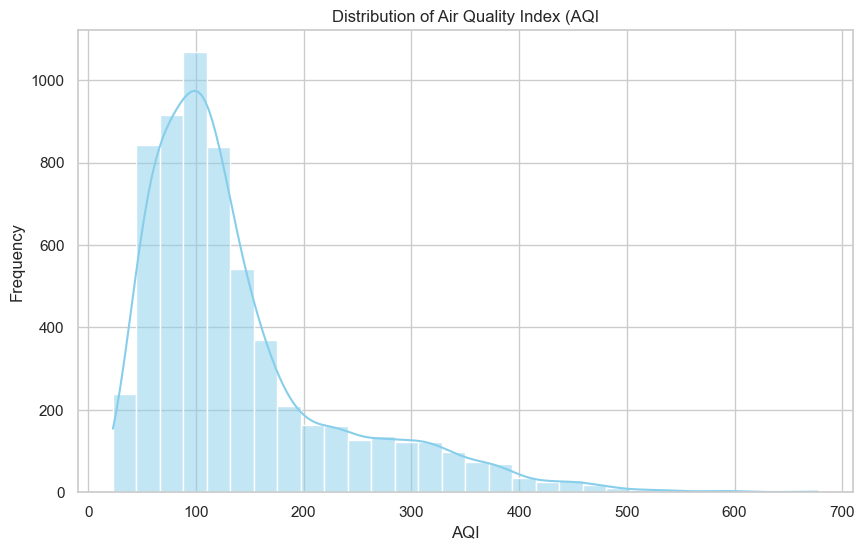

In [82]:
plt.figure(figsize=(10,6))
sns.histplot(data_cleaned['AQI'], bins=30, kde=True, color='skyblue')
plt.title('Distribution of Air Quality Index (AQI')
plt.xlabel('AQI')
plt.ylabel('Frequency')
plt.show()

* Skewness:
The distribution is positively skewed (right-skewed), as most of the AQI values are concentrated in the lower range (below 200), with a long tail extending to the right.

* Peak/Mode:
The highest frequency of AQI values occurs around 100, indicating that this is the most common AQI range.

* Range:
The AQI values span from near 0 to around 700, but values beyond 500 are rare.

* Smooth Density Curve:
The density curve adds visual clarity, showing the general trend of AQI distribution and helping highlight the tail.

**City-wise AQI Analysis**

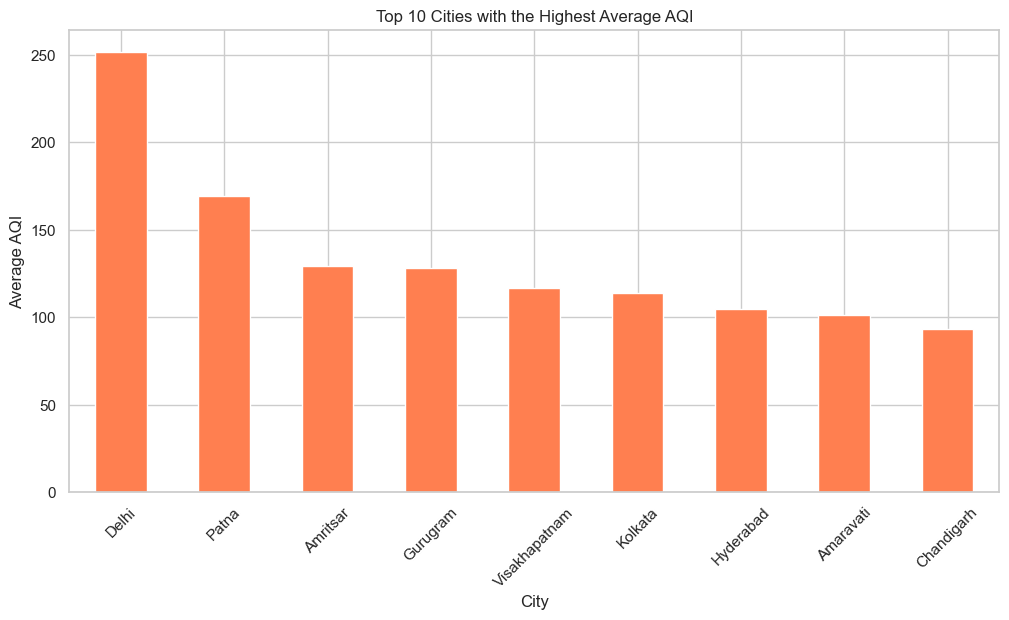

In [83]:
city_aqi = data_cleaned.groupby('City')['AQI'].mean().sort_values(ascending=False).head(10)

plt.figure(figsize=(12,6))
city_aqi.plot(kind='bar',color='coral')
plt.title('Top 10 Cities with the Highest Average AQI')
plt.xlabel('City')
plt.ylabel('Average AQI')
plt.xticks(rotation=45)
plt.show()

In [84]:
unique_cities = data_cleaned['City'].nunique()
print(f"The total number of unique cities in the dataset is {unique_cities}.")

The total number of unique cities in the dataset is 9.


**AQI Trends Over Time**

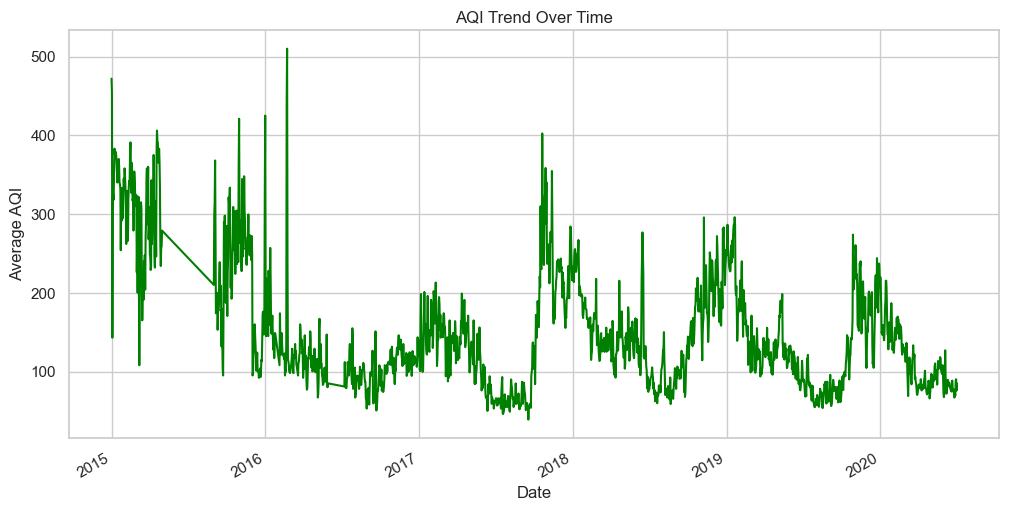

In [85]:
plt.figure(figsize=(12,6))
data_cleaned.groupby('Date')['AQI'].mean().plot(color='green')
plt.title('AQI Trend Over Time')
plt.xlabel('Date')
plt.ylabel('Average AQI')
plt.show()

**PM2.5 and PM10 Levels Analysis**

Comparing the distributions of PM2.5 and PM10

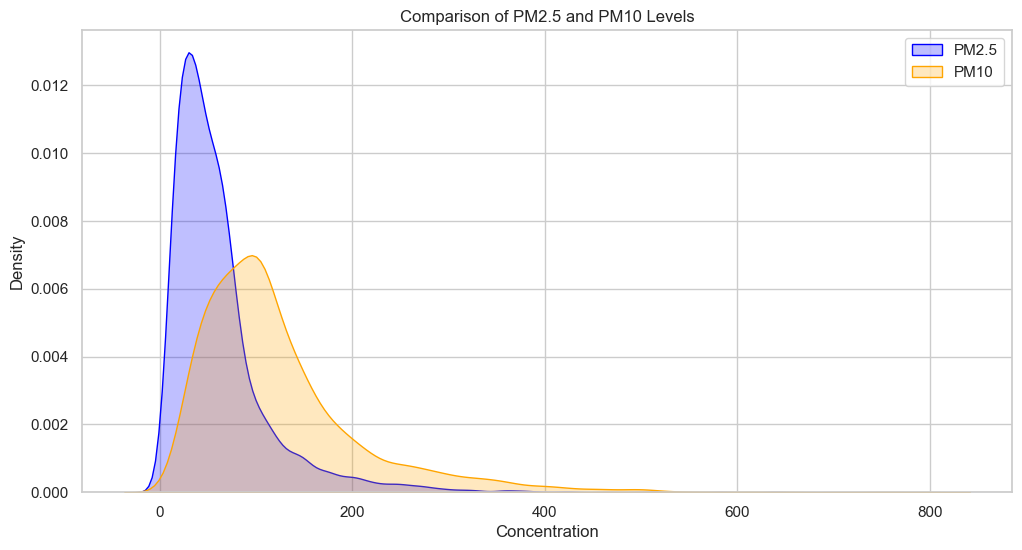

In [86]:
plt.figure(figsize=(12,6))
sns.kdeplot(data_cleaned['PM2.5'], label='PM2.5', color='blue', fill=True)
sns.kdeplot(data_cleaned['PM10'], label='PM10', color='orange', fill=True)

plt.title('Comparison of PM2.5 and PM10 Levels')
plt.xlabel('Concentration')
plt.ylabel('Density')
plt.legend()
plt.show()

**AQI Bucket Distribution**

C:\Users\Lenovo\AppData\Local\Temp\ipykernel_28548\863101188.py:5: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(x='AQI_Bucket', data=data_cleaned, palette='viridis')  # Corrected here


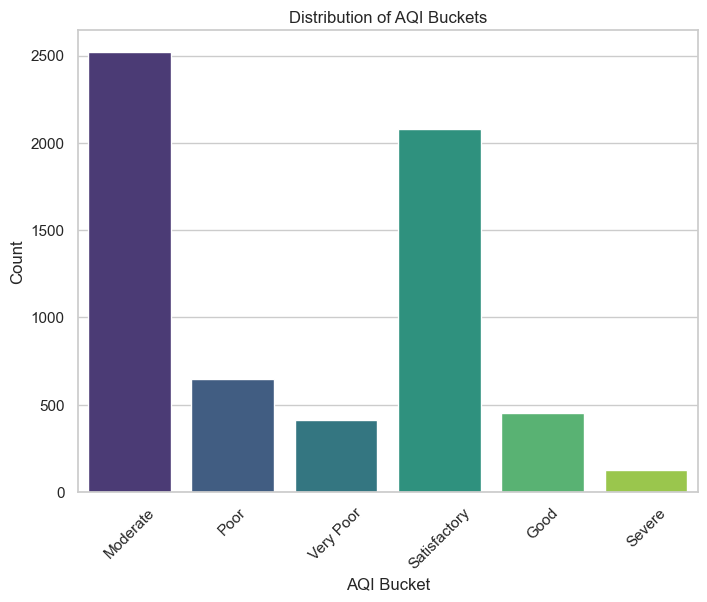

In [87]:
import matplotlib.pyplot as plt
import seaborn as sns

plt.figure(figsize=(8, 6))
sns.countplot(x='AQI_Bucket', data=data_cleaned, palette='viridis')  # Corrected here
plt.title('Distribution of AQI Buckets')
plt.xlabel('AQI Bucket')
plt.ylabel('Count')
plt.xticks(rotation=45)
plt.show()


Observations:

* Dominant Categories:
The "Moderate" category has the highest count, followed by the "Satisfactory" category. Together, these two categories dominate the distribution.

* Lower Frequency of Severe Pollution:
The "Severe" category has the lowest count, indicating fewer instances of extremely poor air quality.

* Skew Towards Better Air Quality:
A significant portion of the data lies in the "Satisfactory" and "Moderate" ranges, suggesting that air quality is generally within acceptable levels most of the time.

* Presence of "Poor" and "Very Poor" Levels:
The "Poor" and "Very Poor" categories still account for a considerable share, highlighting occasional concerning pollution levels.
Insights:

* Health Implications:
While the majority of instances fall under "Moderate" and "Satisfactory," the presence of "Poor," "Very Poor," and "Severe" levels indicates episodic periods where air quality could pose health risks, particularly for sensitive groups.

* Seasonal or Geographical Factors:
The distribution might vary significantly across seasons or locations. For example, "Very Poor" and "Severe" levels could align with events like industrial emissions, crop burning, or winter smog.

* Focus on Reduction:
Interventions might be targeted to reduce occurrences in the "Poor" and "Very Poor" categories, as they represent the most manageable opportunities for improvement.

# Answering Questions

**Correlation between AQI and PM2.5**

In [88]:
aqi_pm25_corr = cd[['AQI','PM2.5']].corr().iloc[0,1]
print(f"The correlation between AQI and PM2.5 is {aqi_pm25_corr:.2f}")

The correlation between AQI and PM2.5 is 0.66


**Total Number of Unique Cities in the Dataset**

In [89]:
unique_cities = cd['City'].nunique()
print(f"The total number of unique cities in the dataset is {unique_cities}.")

The total number of unique cities in the dataset is 26.


**Date with the Highest Average AQI**

In [90]:
highest_aqi_date = cd.groupby('Date')['AQI'].mean().idxmax()
highest_aqi_value = cd.groupby('Date')['AQI'].mean().max()

print(f"The data with the highest average AQI is {highest_aqi_date} with an AQI of {highest_aqi_value:.2f}")

The data with the highest average AQI is 2015-02-23 00:00:00 with an AQI of 764.00


**City with the Highest PM2.5 Levels on an Average**

In [91]:
city_highest_pm25 = cd.groupby('City')['PM2.5'].mean().idxmax()
highest_pm25_value = cd.groupby('City')['PM2.5'].mean().max()

print(f"The city with the highest average PM2.5 is {city_highest_pm25} with PM2.5 concentration of {highest_pm25_value:.2f}")

The city with the highest average PM2.5 is Patna with PM2.5 concentration of 123.50


**Correlation between AQI and PM2.5**

In [92]:
aqi_pm25_corr = cd[['AQI','PM2.5']].corr().iloc[0,1]
print(f"The correlation between AQI and PM2.5 is {aqi_pm25_corr:.2f}")

The correlation between AQI and PM2.5 is 0.66


**Overall Average for Key Pollutants**

In [93]:
pollutants = ['PM2.5','PM10','NO','NO2','NOx','NH3','CO','SO2','O3','Benzene','Toluene','Xylene']
pollutants_avg = cd[pollutants].mean()

print("Overall Average Values for Key Pollutants:")
print(pollutants_avg)

Overall Average Values for Key Pollutants:
PM2.5       67.450578
PM10       118.127103
NO          17.574730
NO2         28.560659
NOx         32.309123
NH3         23.483476
CO           2.248598
SO2         14.531977
O3          34.491430
Benzene      3.280840
Toluene      8.700972
Xylene       3.070128
dtype: float64


**Number of Days with AQI > 300 (Severe Air Quality)**

In [94]:
severe_aqi_days = (cd['AQI'] > 300).sum()
print(f"The number of days with AQI greater than 300 (severe) is {severe_aqi_days}.")

The number of days with AQI greater than 300 (severe) is 3675.


**Top 5 cities with maximum variance in AQI**

In [95]:
city_aqi_variance = cd.groupby('City')['AQI'].var().sort_values(ascending=False).head(5)

print("Top 5 Cities with Maximum AQI Variance:")
print(city_aqi_variance)

Top 5 Cities with Maximum AQI Variance:
City
Ahmedabad    97175.314207
Patna        14967.491557
Gurugram     14386.378582
Delhi        14289.173899
Lucknow      13680.293671
Name: AQI, dtype: float64


Dataset shape: (29531, 16)
Numeric pollutant columns used: ['PM2.5', 'PM10', 'NO', 'NO2', 'NOx', 'NH3', 'CO', 'SO2', 'O3', 'Benzene', 'Toluene', 'Xylene', 'AQI']

Descriptive statistics:


,mean,median,std,min,25%,50%,75%,max,range
PM2.5,67.450578,48.57,64.661449,0.04,28.820,48.57,80.5900,949.99,949.95
PM10,118.127103,95.68,90.605110,0.01,56.255,95.68,149.7450,1000.00,999.99
NO,17.574730,9.89,22.785846,0.02,5.630,9.89,19.9500,390.68,390.66
NO2,28.560659,21.69,24.474746,0.01,11.750,21.69,37.6200,362.21,362.20
NOx,32.309123,23.52,31.646011,0.00,12.820,23.52,40.1275,467.63,467.63
NH3,23.483476,15.85,25.684275,0.01,8.580,15.85,30.0200,352.89,352.88
CO,2.248598,0.89,6.962884,0.00,0.510,0.89,1.4500,175.81,175.81
SO2,14.531977,9.16,18.133775,0.01,5.670,9.16,15.2200,193.86,193.85
O3,34.491430,30.84,21.694928,0.01,18.860,30.84,45.5700,257.73,257.72
Benzene,3.280840,1.07,15.811136,0.00,0.120,1.07,3.0800,455.03,455.03



Missing values (selected columns):


,missing_count
Xylene,18109
PM10,11140
NH3,10328
Toluene,8041
Benzene,5623
AQI,4681
PM2.5,4598
NOx,4185
O3,4022
SO2,3854


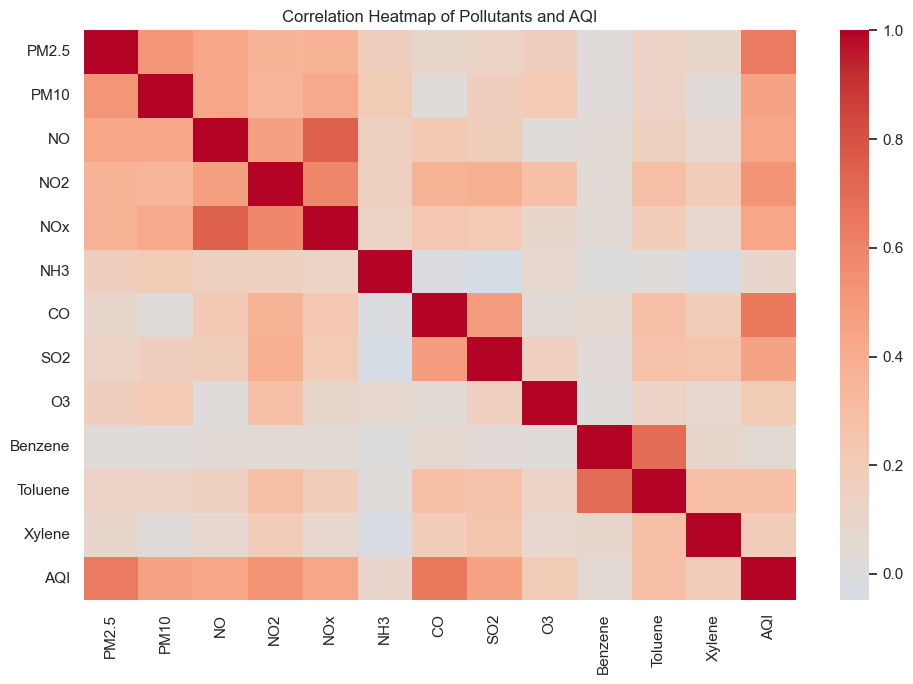

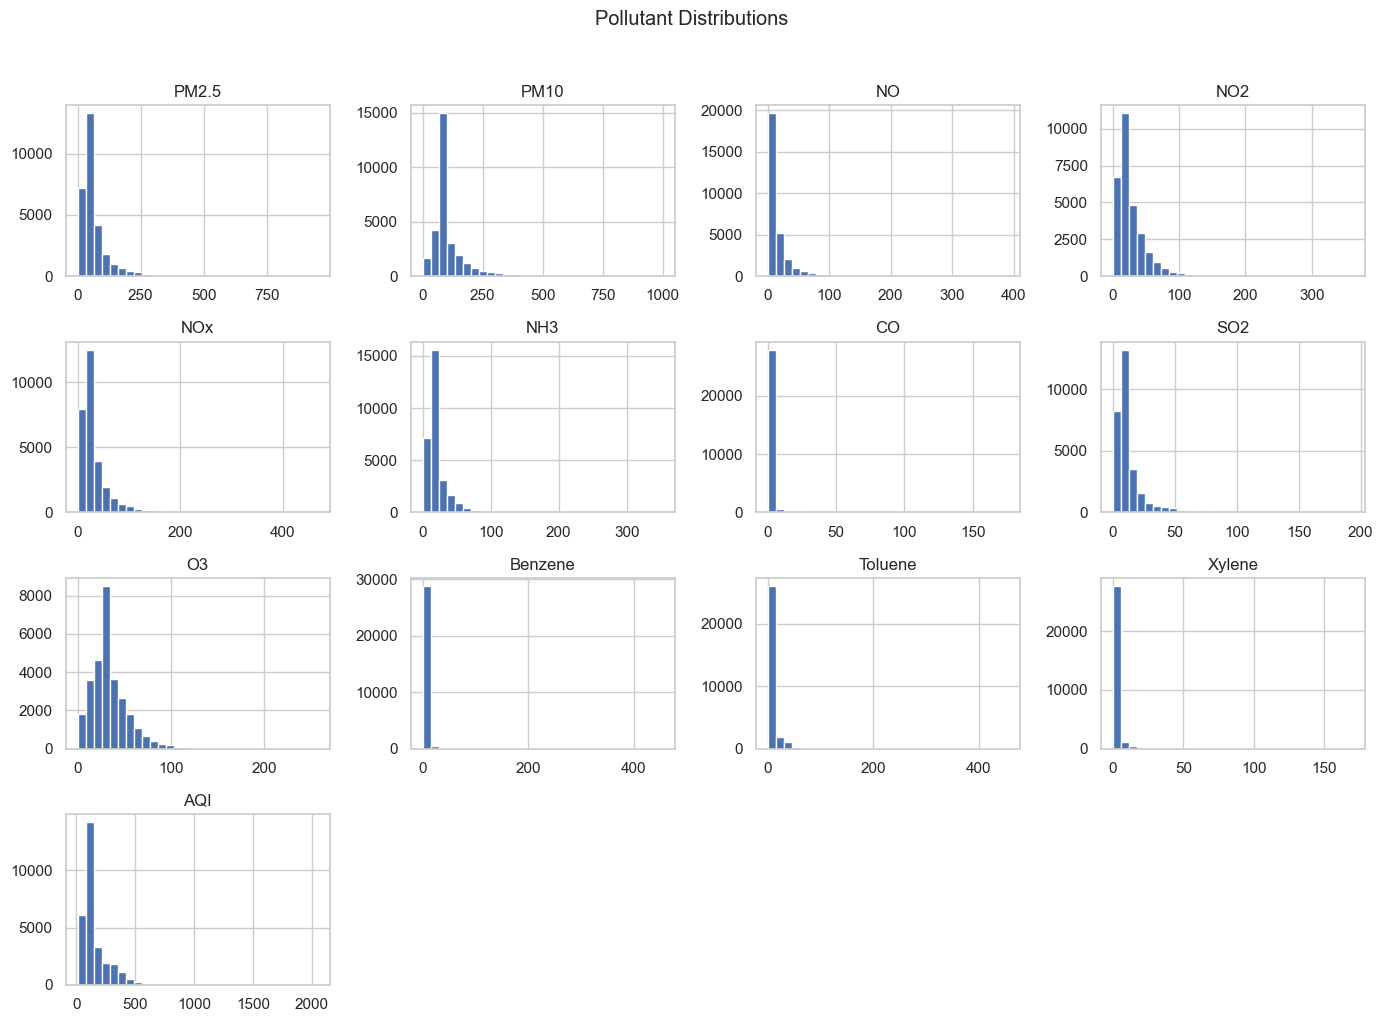

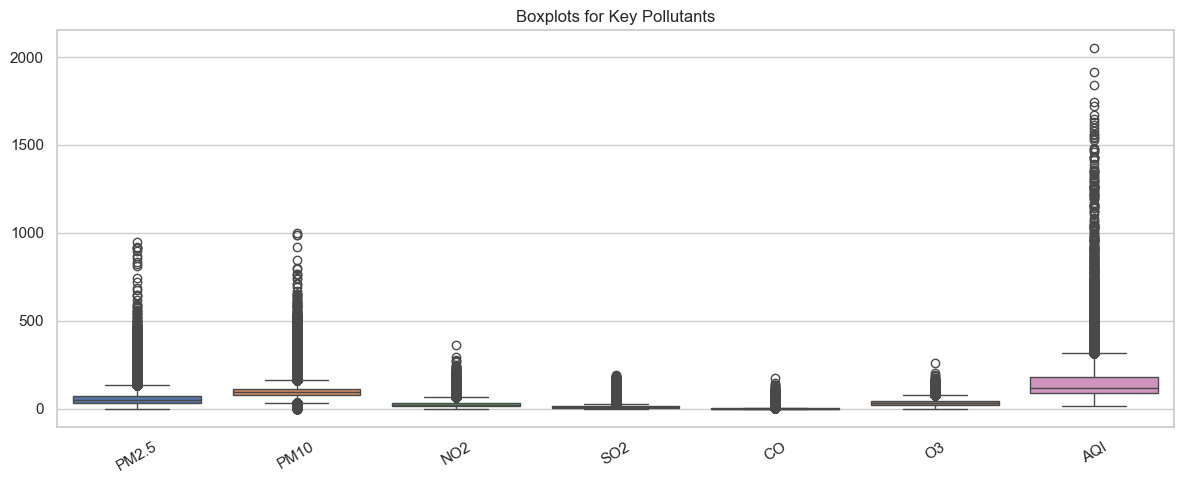

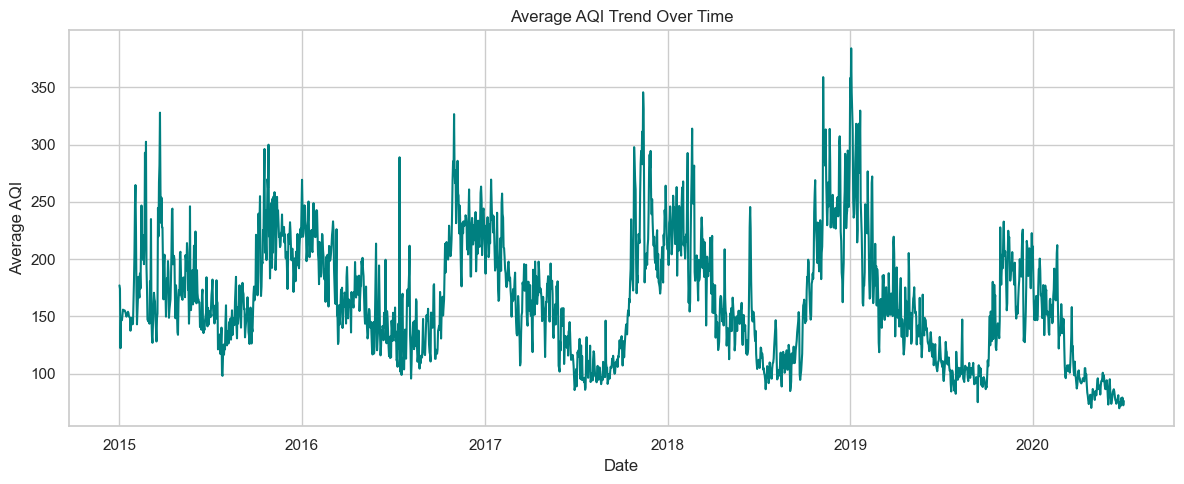

In [96]:
import os
import numpy as np
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

sns.set(style="whitegrid")

candidate_paths = ["data/city_day.csv", "city_day.csv"]
chosen_path = None
for p in candidate_paths:
    if os.path.exists(p):
        chosen_path = p
        break

if chosen_path is None:
    raise FileNotFoundError("city_day.csv not found. Place it at data/city_day.csv or city_day.csv")

df = pd.read_csv(chosen_path)
if "Date" in df.columns:
    df["Date"] = pd.to_datetime(df["Date"], errors="coerce")

pollutants = ["PM2.5", "PM10", "NO", "NO2", "NOx", "NH3", "CO", "SO2", "O3", "Benzene", "Toluene", "Xylene", "AQI"]
available_num = [c for c in pollutants if c in df.columns]

print("Dataset shape:", df.shape)
print("Numeric pollutant columns used:", available_num)

# Descriptive statistics and dispersion summary
stats_df = df[available_num].describe().T
stats_df["median"] = df[available_num].median()
stats_df["range"] = stats_df["max"] - stats_df["min"]
stats_df = stats_df[["mean", "median", "std", "min", "25%", "50%", "75%", "max", "range"]]
print("\nDescriptive statistics:")
display(stats_df)

missing = df[available_num].isna().sum().sort_values(ascending=False)
print("\nMissing values (selected columns):")
display(missing.to_frame("missing_count"))

df_clean = df.copy()
df_clean[available_num] = df_clean[available_num].fillna(df_clean[available_num].median(numeric_only=True))

# Correlation heatmap
plt.figure(figsize=(10, 7))
sns.heatmap(df_clean[available_num].corr(), annot=False, cmap="coolwarm", center=0)
plt.title("Correlation Heatmap of Pollutants and AQI")
plt.tight_layout()
plt.show()

df_clean[available_num].hist(figsize=(14, 10), bins=30)
plt.suptitle("Pollutant Distributions", y=1.02)
plt.tight_layout()
plt.show()

box_cols = [c for c in ["PM2.5", "PM10", "NO2", "SO2", "CO", "O3", "AQI"] if c in available_num]
if box_cols:
    plt.figure(figsize=(12, 5))
    sns.boxplot(data=df_clean[box_cols])
    plt.title("Boxplots for Key Pollutants")
    plt.xticks(rotation=30)
    plt.tight_layout()
    plt.show()

if "Date" in df_clean.columns and "AQI" in df_clean.columns:
    trend = df_clean.dropna(subset=["Date"]).groupby("Date", as_index=False)["AQI"].mean().sort_values("Date")
    plt.figure(figsize=(12, 5))
    plt.plot(trend["Date"], trend["AQI"], color="teal")
    plt.title("Average AQI Trend Over Time")
    plt.xlabel("Date")
    plt.ylabel("Average AQI")
    plt.tight_layout()
    plt.show()
